## I. DATA UNDERSTANDING

### 1. IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set(style="whitegrid")

### 2. LOAD DATA

In [2]:
df = pd.read_csv("student_depression_dataset.csv")
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


### 3. DATA STRUCTURE OVERVIEW

In [3]:
print("TAIL = ")
display(df.tail())

TAIL = 


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
27896,140685,Female,27.0,Surat,Student,5.0,0.0,5.75,5.0,0.0,'5-6 hours',Unhealthy,'Class 12',Yes,7.0,1.0,Yes,0
27897,140686,Male,27.0,Ludhiana,Student,2.0,0.0,9.40,3.0,0.0,'Less than 5 hours',Healthy,MSc,No,0.0,3.0,Yes,0
27898,140689,Male,31.0,Faridabad,Student,3.0,0.0,6.61,4.0,0.0,'5-6 hours',Unhealthy,MD,No,12.0,2.0,No,0
27899,140690,Female,18.0,Ludhiana,Student,5.0,0.0,6.88,2.0,0.0,'Less than 5 hours',Healthy,'Class 12',Yes,10.0,5.0,No,1
27900,140699,Male,27.0,Patna,Student,4.0,0.0,9.24,1.0,0.0,'Less than 5 hours',Healthy,BCA,Yes,2.0,3.0,Yes,1


In [4]:
print("DATA INFO = ")
print(df.info())

DATA INFO = 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  ob

In [5]:
print("DATA SHAPE = ")
print(df.shape)

print("\nDATA COLUMNS = ")
print(df.columns)

DATA SHAPE = 
(27901, 18)

DATA COLUMNS = 
Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')


### 4. DATA TYPES (NUMERIC-CATEGORICAL)

In [6]:
print("\n DATA TYPES = ")
print(df.dtypes)

num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print("\n NUMERIC COLUMNS = ", num_cols)
print("\n CATEGORICAL COLUMNS = ", cat_cols)


 DATA TYPES = 
id                                         int64
Gender                                    object
Age                                      float64
City                                      object
Profession                                object
Academic Pressure                        float64
Work Pressure                            float64
CGPA                                     float64
Study Satisfaction                       float64
Job Satisfaction                         float64
Sleep Duration                            object
Dietary Habits                            object
Degree                                    object
Have you ever had suicidal thoughts ?     object
Work/Study Hours                         float64
Financial Stress                          object
Family History of Mental Illness          object
Depression                                 int64
dtype: object

 NUMERIC COLUMNS =  ['id', 'Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study 

### 5. MISSING VALUE ANALYSIS


TOTAL MISSING VALUES
id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64


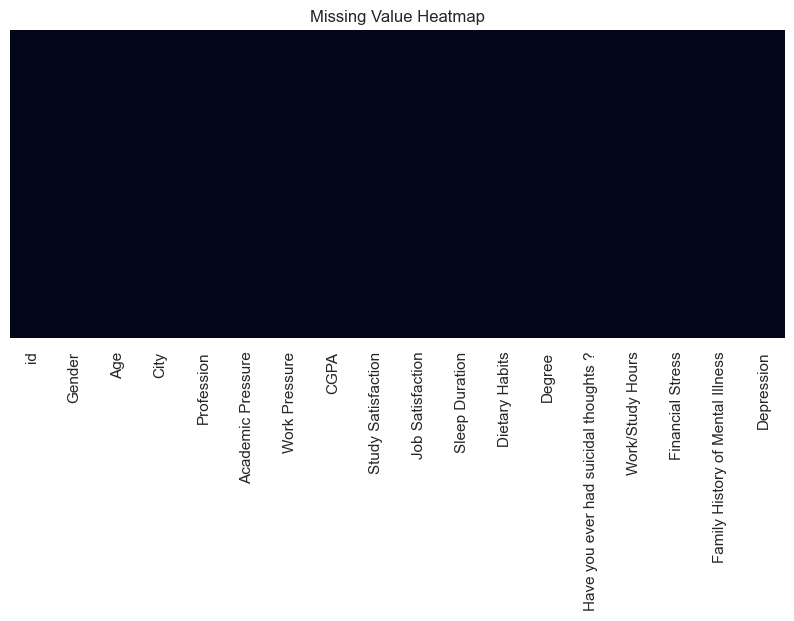

In [7]:
print("\nTOTAL MISSING VALUES")
print(df.isnull().sum())

plt.figure(figsize=(10,4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Value Heatmap")
plt.show()

###  6. DUPLICATE CHECK

In [8]:
print("DUPLICATED ROWS = ")
print(df.duplicated().sum())

DUPLICATED ROWS = 
0


### 7. DESCRIPTIVE STATISTICS

In [9]:
print("\n NUMERICAL SUMMARY")
display(df.describe())


 NUMERICAL SUMMARY


,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000
mean,70442.149421,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,0.585499
std,40641.175216,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,0.492645
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35039.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,0.000000
50%,70684.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,1.000000
75%,105818.000000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,1.000000


In [10]:
print("\n CATEGORICAL SUMMARY")
display(df.describe(include='object'))


 CATEGORICAL SUMMARY


,Gender,City,Profession,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Financial Stress,Family History of Mental Illness
count,27901,27901,27901,27901,27901,27901,27901,27901,27901
unique,2,52,14,5,4,28,2,6,2
top,Male,Kalyan,Student,'Less than 5 hours',Unhealthy,'Class 12',Yes,5.0,No
freq,15547,1570,27870,8310,10317,6080,17656,6715,14398


In [11]:
for col in cat_cols:
    print("=" * 80)
    print(f"Kolom: {col}")
    print(f"Jumlah unique value: {df[col].nunique(dropna=False)}")
    print("Unique values:")
    print(df[col].drop_duplicates().tolist())
    print()

Kolom: Gender
Jumlah unique value: 2
Unique values:
['Male', 'Female']

Kolom: City
Jumlah unique value: 52
Unique values:
['Visakhapatnam', 'Bangalore', 'Srinagar', 'Varanasi', 'Jaipur', 'Pune', 'Thane', 'Chennai', 'Nagpur', 'Nashik', 'Vadodara', 'Kalyan', 'Rajkot', 'Ahmedabad', 'Kolkata', 'Mumbai', 'Lucknow', 'Indore', 'Surat', 'Ludhiana', 'Bhopal', 'Meerut', 'Agra', 'Ghaziabad', 'Hyderabad', 'Vasai-Virar', 'Kanpur', 'Patna', 'Faridabad', 'Delhi', 'Saanvi', 'M.Tech', 'Bhavna', "'Less Delhi'", 'City', '3.0', "'Less than 5 Kalyan'", 'Mira', 'Harsha', 'Vaanya', 'Gaurav', 'Harsh', 'Reyansh', 'Kibara', 'Rashi', 'ME', 'M.Com', 'Nalyan', 'Mihir', 'Nalini', 'Nandini', 'Khaziabad']

Kolom: Profession
Jumlah unique value: 14
Unique values:
['Student', "'Civil Engineer'", 'Architect', "'UX/UI Designer'", "'Digital Marketer'", "'Content Writer'", "'Educational Consultant'", 'Teacher', 'Manager', 'Chef', 'Doctor', 'Lawyer', 'Entrepreneur', 'Pharmacist']

Kolom: Sleep Duration
Jumlah unique value:

### 8. DISTRIBUTION ANALYSIS


 DISTRIBUTION PLOTS: NUMERICAL


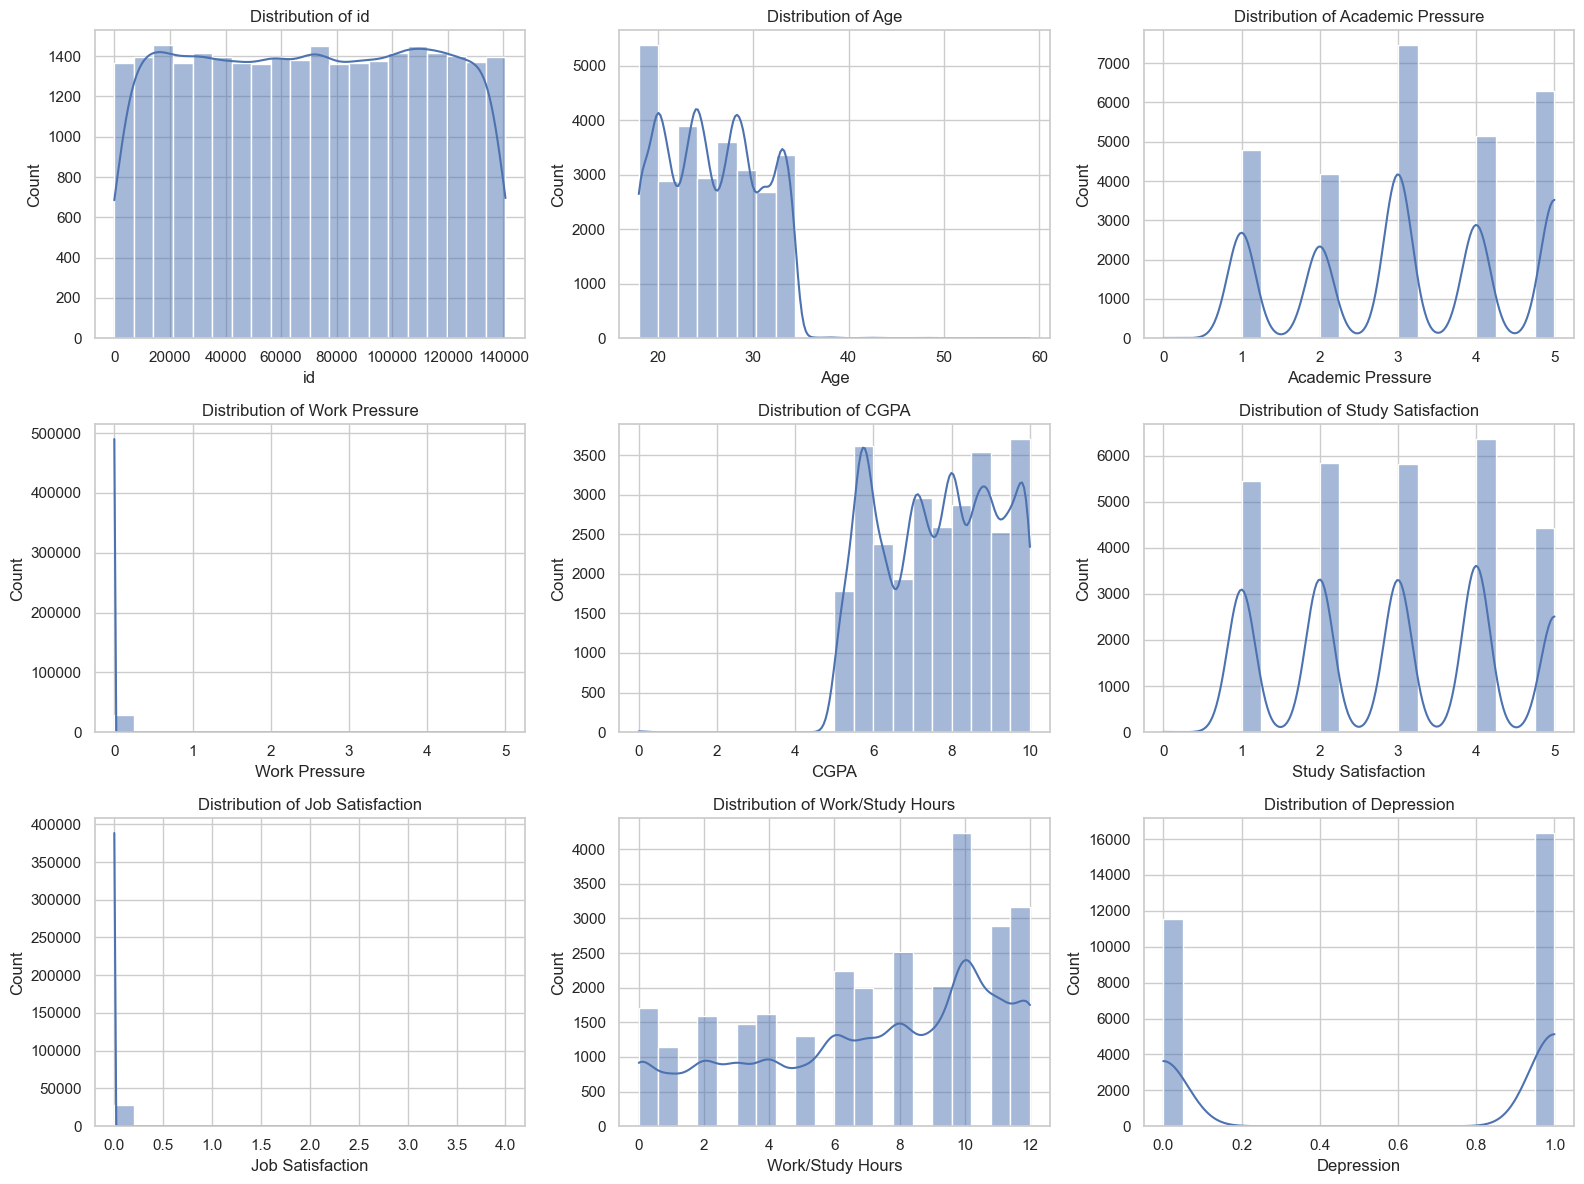

In [12]:
print("\n DISTRIBUTION PLOTS: NUMERICAL")
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16,12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=20)
    axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()


 DISTRIBUTION PLOTS: CATEGORICAL


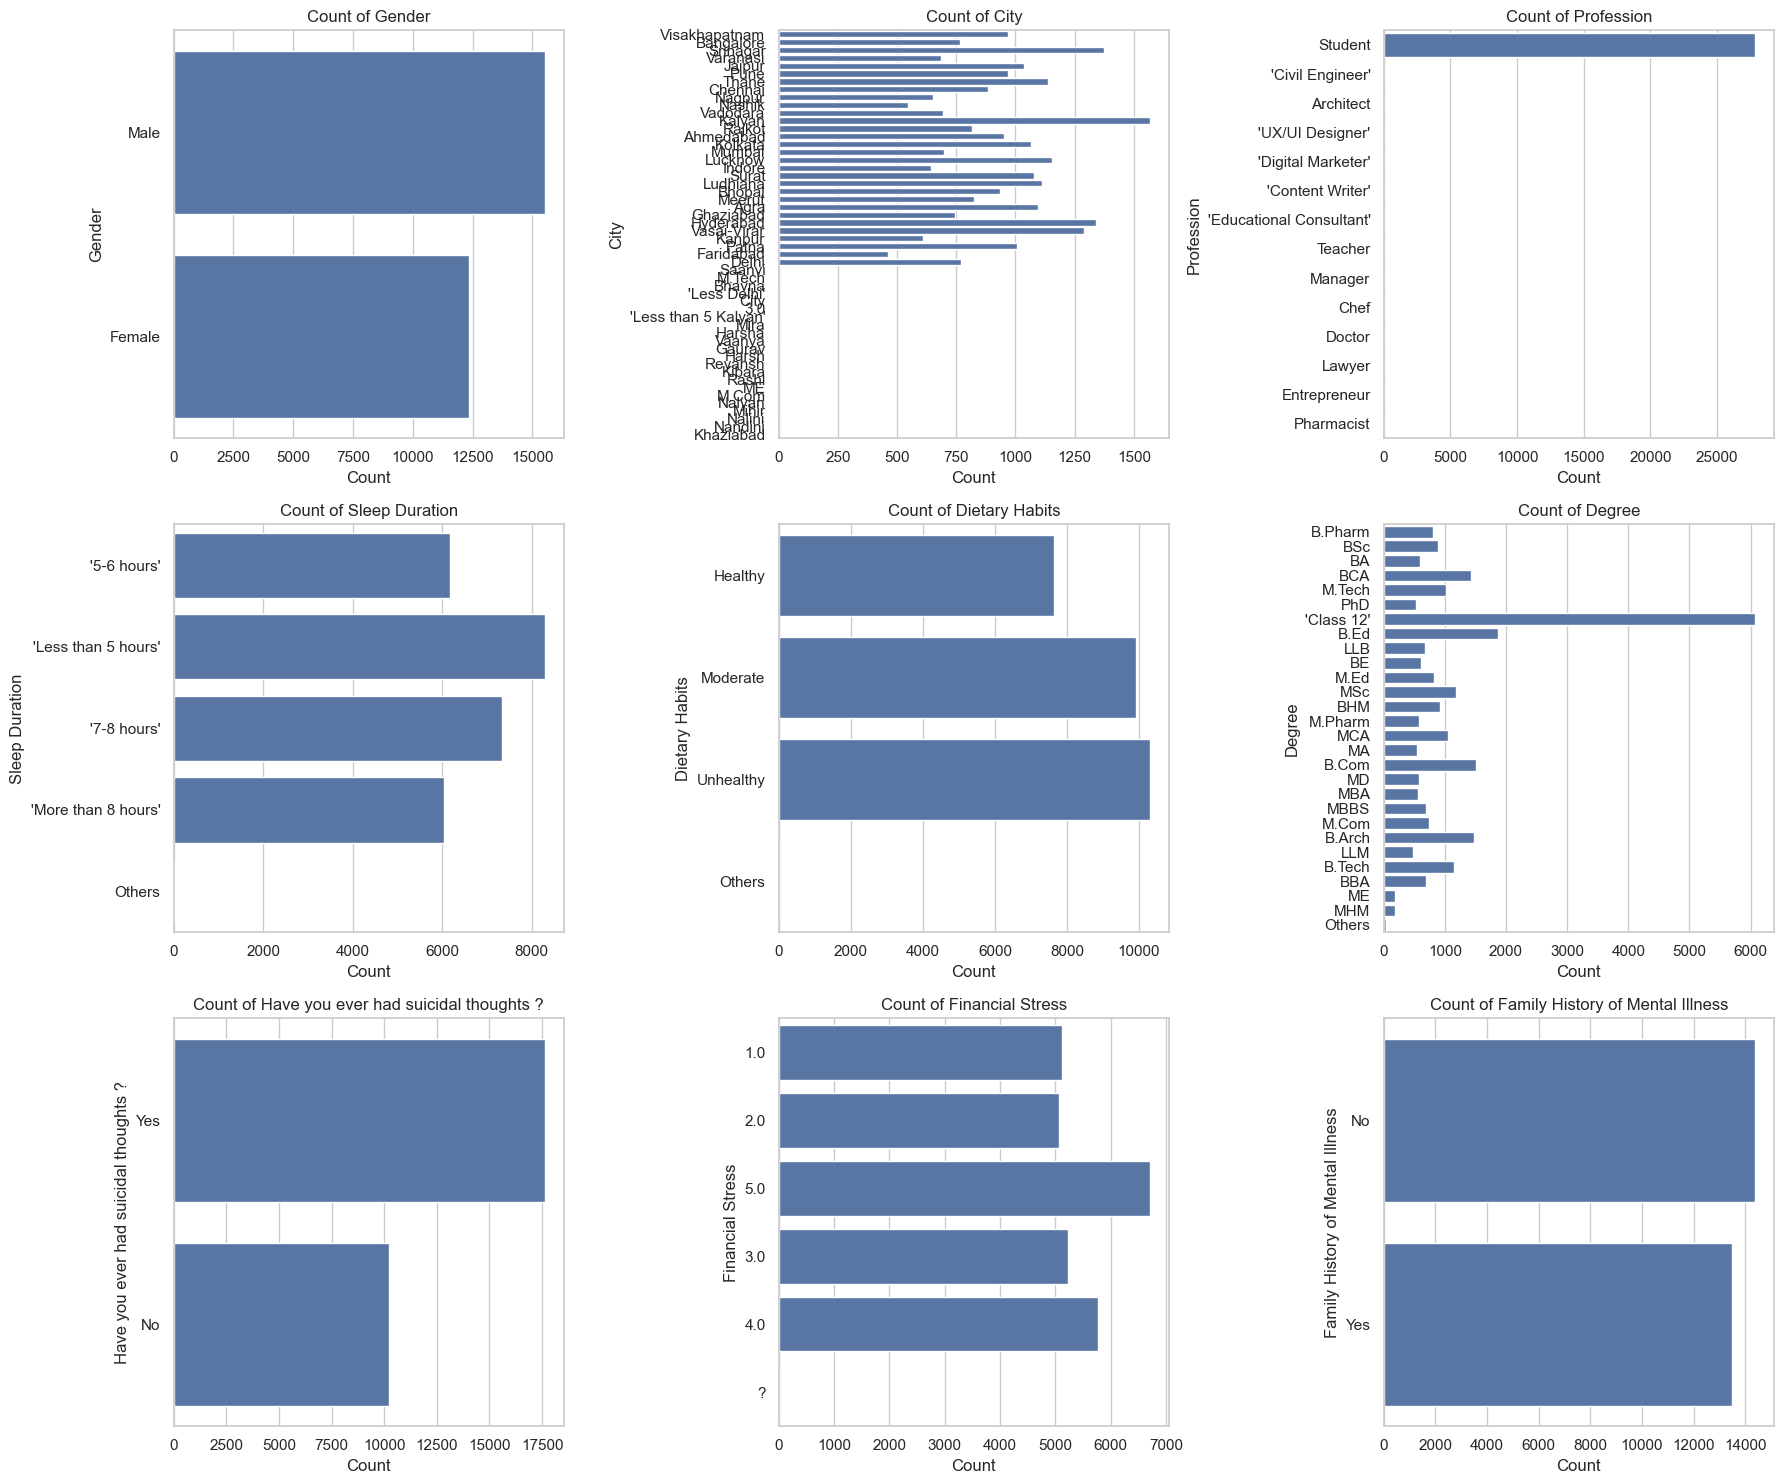

In [13]:
print("\n DISTRIBUTION PLOTS: CATEGORICAL")
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18,15))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, y=col, ax=axes[i])
    axes[i].set_title(f"Count of {col}")
    axes[i].set_xlabel("Count")

plt.tight_layout()
plt.show()

### 9. SKEWNESS CHECK

Work Pressure         108.594361
Job Satisfaction       74.105663
Age                     0.132239
Study Satisfaction      0.010423
id                     -0.005380
CGPA                   -0.113063
Academic Pressure      -0.135165
Depression             -0.347126
Work/Study Hours       -0.454769
dtype: float64


C:\Users\leciti\AppData\Local\Temp\ipykernel_17436\3813697507.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=skew_vals.index, y=skew_vals.values, palette="magma")


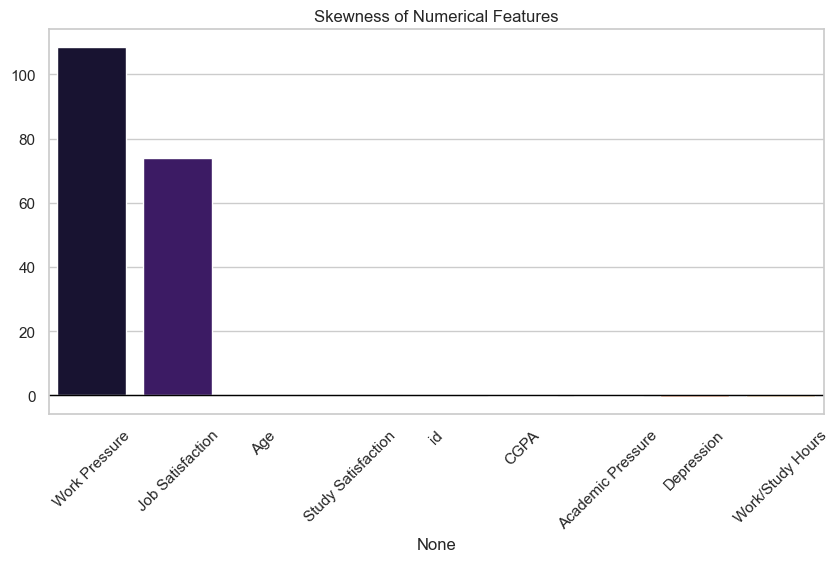

In [14]:
skew_vals = df[num_cols].skew().sort_values(ascending=False)
print(skew_vals)

plt.figure(figsize=(10,5))
sns.barplot(x=skew_vals.index, y=skew_vals.values, palette="magma")
plt.title("Skewness of Numerical Features")
plt.axhline(0, color="black", linewidth=1)
plt.xticks(rotation=45)
plt.show()

### 10. OUTLIER DETECTION

In [15]:
zscore_outliers = {}
iqr_outliers = {}

for col in num_cols:
    skew = skew_vals[col]
    print(f"\n--- Column: {col} ---")
    print(f"Skewness: {skew:.3f}")

    if abs(skew) < 0.5:
        print("Method: Z-score")
        z = np.abs(stats.zscore(df[col]))
        outlier_idx = df[z > 3].index
        zscore_outliers[col] = list(outlier_idx)
        print(f"Outliers detected: {len(outlier_idx)} rows")

    else:
        print("Method: IQR")
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outlier_idx = df[(df[col] < lower) | (df[col] > upper)].index
        iqr_outliers[col] = list(outlier_idx)
        print(f"Outliers detected: {len(outlier_idx)} rows")


--- Column: id ---
Skewness: -0.005
Method: Z-score
Outliers detected: 0 rows

--- Column: Age ---
Skewness: 0.132
Method: Z-score
Outliers detected: 19 rows

--- Column: Academic Pressure ---
Skewness: -0.135
Method: Z-score
Outliers detected: 0 rows

--- Column: Work Pressure ---
Skewness: 108.594
Method: IQR
Outliers detected: 3 rows

--- Column: CGPA ---
Skewness: -0.113
Method: Z-score
Outliers detected: 9 rows

--- Column: Study Satisfaction ---
Skewness: 0.010
Method: Z-score
Outliers detected: 0 rows

--- Column: Job Satisfaction ---
Skewness: 74.106
Method: IQR
Outliers detected: 8 rows

--- Column: Work/Study Hours ---
Skewness: -0.455
Method: Z-score
Outliers detected: 0 rows

--- Column: Depression ---
Skewness: -0.347
Method: Z-score
Outliers detected: 0 rows


### 11. BOXPLOT NUMERICAL FEATURES

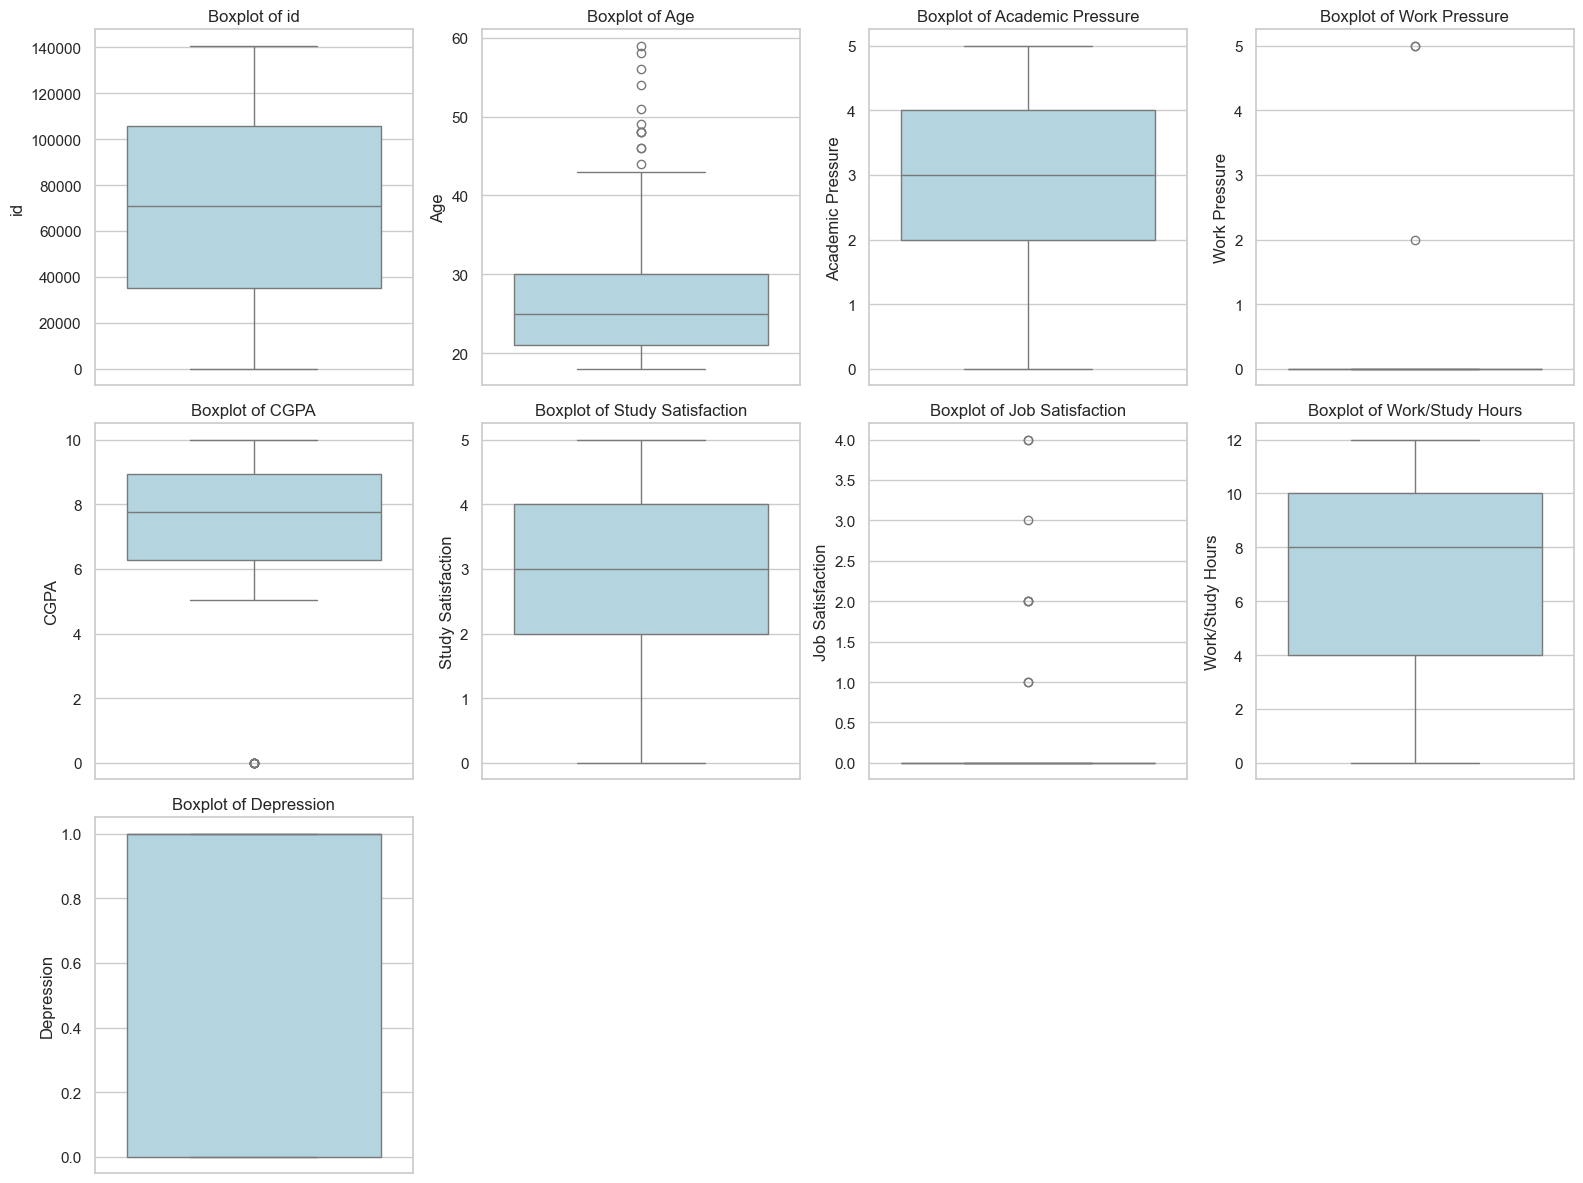

In [16]:
n_cols = len(num_cols)
n_rows = (n_cols + 3) // 4

plt.figure(figsize=(16, 4 * n_rows))
for i, col in enumerate(num_cols):
    plt.subplot(n_rows, 4, i+1)
    sns.boxplot(y=df[col], color='lightblue')
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

### 12. CORELATION (NUMERIC)

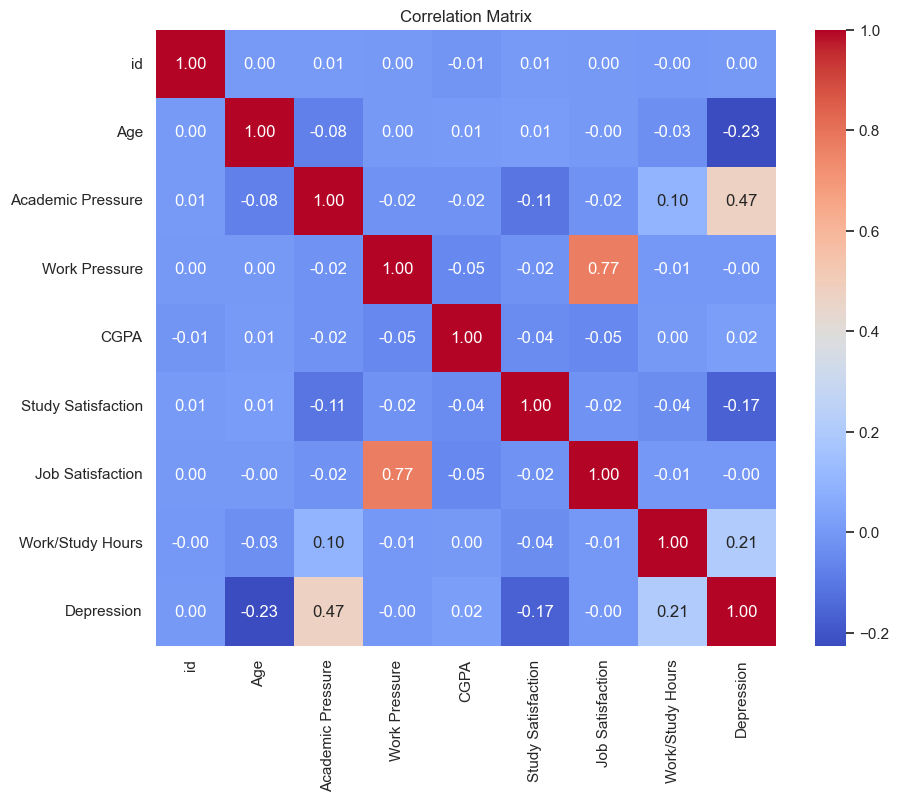

In [17]:
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


In [18]:
import numpy as np
from scipy.stats import chi2_contingency

target = "Depression"

numeric_corr = df[num_cols].corr()[target].sort_values(ascending=False)
numeric_corr

def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k-1, r-1))

cat_cols = [col for col in cat_cols if col != target]

cat_corr = {}

for col in cat_cols:
    cm = pd.crosstab(df[col], df[target])
    cat_corr[col] = cramers_v(cm)

cat_corr = pd.Series(cat_corr).sort_values(ascending=False)
cat_corr

combined_corr = pd.concat([numeric_corr, cat_corr], axis=0)
combined_corr.name = "Correlation_to_Depression"
combined_corr



Depression                               1.000000
Academic Pressure                        0.474835
Work/Study Hours                         0.208563
CGPA                                     0.022210
id                                       0.000923
Work Pressure                           -0.003351
Job Satisfaction                        -0.003482
Study Satisfaction                      -0.167971
Age                                     -0.226422
Have you ever had suicidal thoughts ?    0.546201
Financial Stress                         0.364312
Dietary Habits                           0.207614
Degree                                   0.138001
Sleep Duration                           0.099612
City                                     0.082072
Family History of Mental Illness         0.053357
Profession                               0.022630
Gender                                   0.001721
Name: Correlation_to_Depression, dtype: float64

C:\Users\leciti\AppData\Local\Temp\ipykernel_17436\3144274949.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=combined_corr.values, y=combined_corr.index, palette="coolwarm")


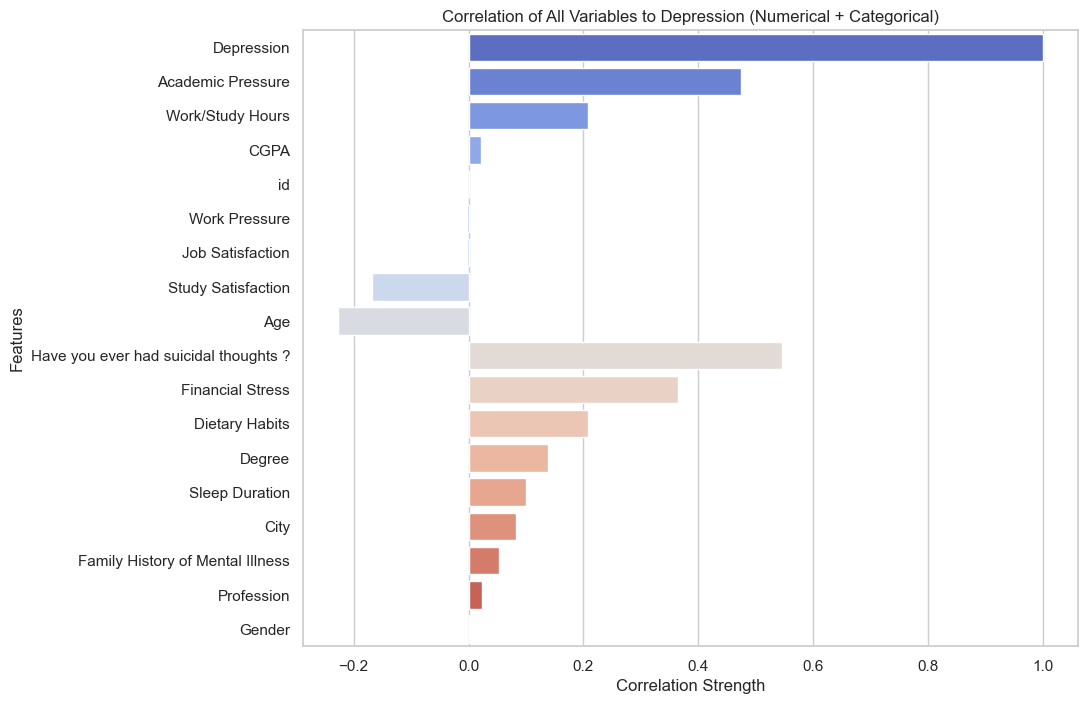

In [19]:
plt.figure(figsize=(10, 8))
sns.barplot(x=combined_corr.values, y=combined_corr.index, palette="coolwarm")
plt.title("Correlation of All Variables to Depression (Numerical + Categorical)")
plt.xlabel("Correlation Strength")
plt.ylabel("Features")
plt.show()

### 13. TARGET IMBALANCE CHECK


TARGET CLASS DISTRIBUTION
Depression
1    16336
0    11565
Name: count, dtype: int64

TARGET CLASS PERCENTAGE
Depression
1    58.55
0    41.45
Name: proportion, dtype: float64


C:\Users\leciti\AppData\Local\Temp\ipykernel_17436\666316859.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette="coolwarm")


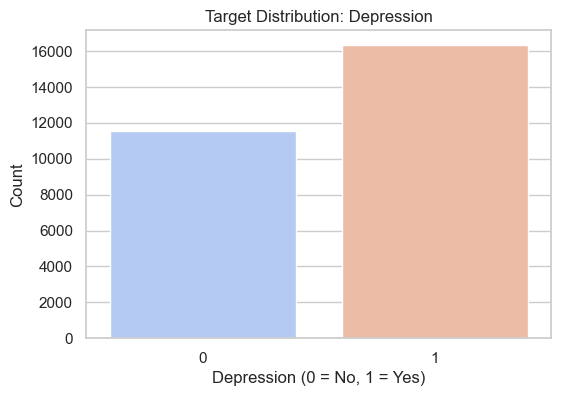

In [20]:
target_col = "Depression"

print("\nTARGET CLASS DISTRIBUTION")
print(df[target_col].value_counts())

print("\nTARGET CLASS PERCENTAGE")
print((df[target_col].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df, palette="coolwarm")
plt.title("Target Distribution: Depression")
plt.xlabel("Depression (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

### 14. NUMERIC vs TARGET RELATION (BOXPLOT)


NUMERICAL FEATURES VS TARGET



C:\Users\leciti\AppData\Local\Temp\ipykernel_17436\1265384044.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y=col, data=df, palette="Set2")


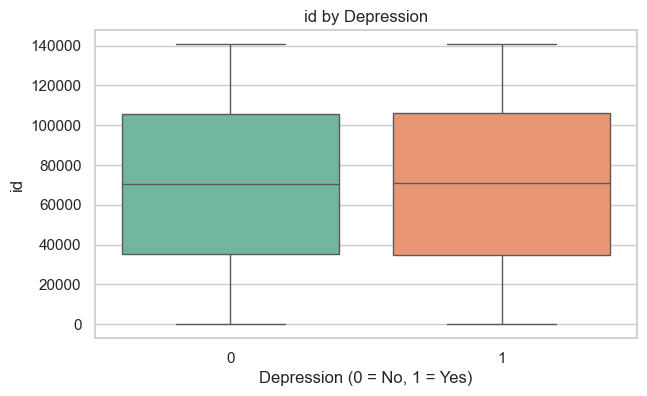

C:\Users\leciti\AppData\Local\Temp\ipykernel_17436\1265384044.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y=col, data=df, palette="Set2")


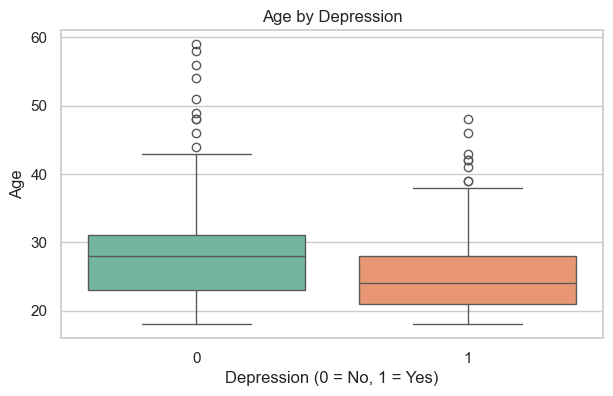

C:\Users\leciti\AppData\Local\Temp\ipykernel_17436\1265384044.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y=col, data=df, palette="Set2")


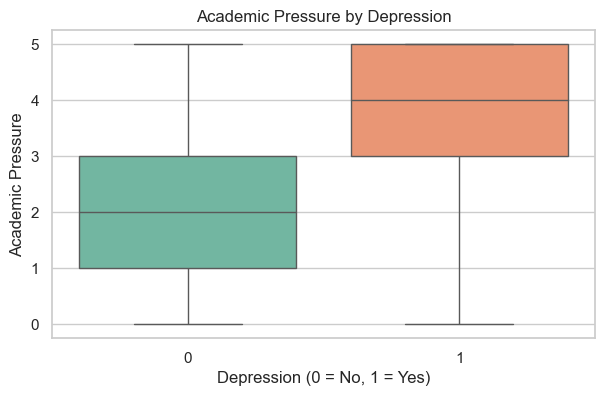

C:\Users\leciti\AppData\Local\Temp\ipykernel_17436\1265384044.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y=col, data=df, palette="Set2")


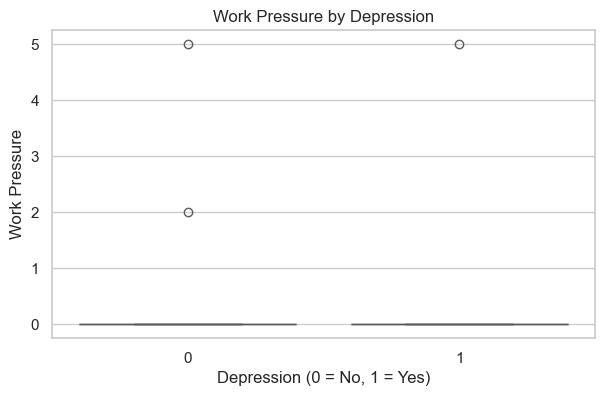

C:\Users\leciti\AppData\Local\Temp\ipykernel_17436\1265384044.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y=col, data=df, palette="Set2")


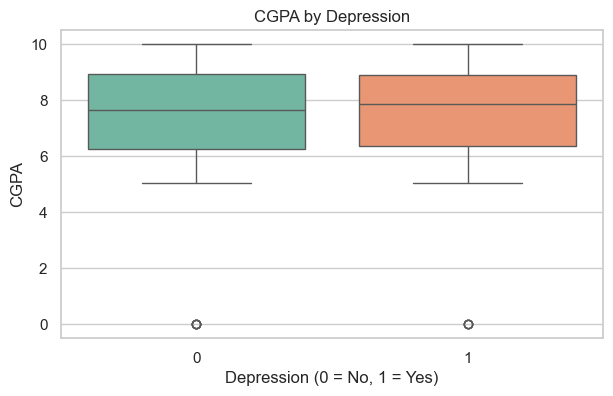

C:\Users\leciti\AppData\Local\Temp\ipykernel_17436\1265384044.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y=col, data=df, palette="Set2")


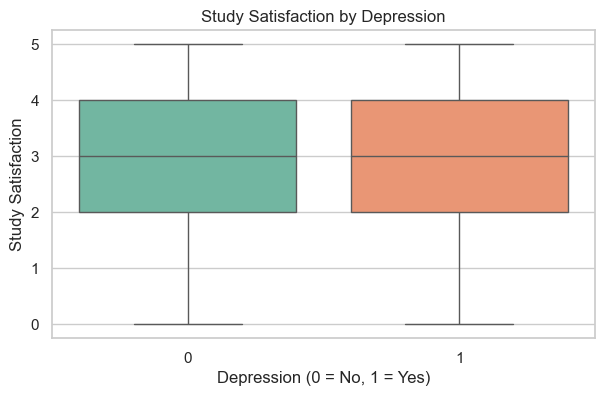

C:\Users\leciti\AppData\Local\Temp\ipykernel_17436\1265384044.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y=col, data=df, palette="Set2")


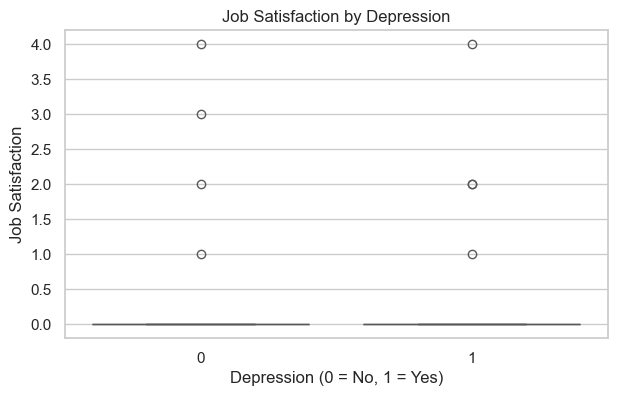

C:\Users\leciti\AppData\Local\Temp\ipykernel_17436\1265384044.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y=col, data=df, palette="Set2")


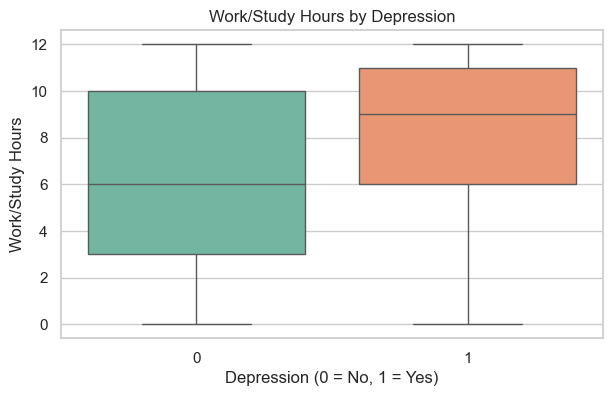

In [21]:
print("\nNUMERICAL FEATURES VS TARGET\n")

for col in num_cols:
    if col != target_col:  
        plt.figure(figsize=(7,4))
        sns.boxplot(x=target_col, y=col, data=df, palette="Set2")
        plt.title(f"{col} by Depression")
        plt.xlabel("Depression (0 = No, 1 = Yes)")
        plt.show()


### 15. CATEGORICAL vs TARGET RELATION


===== Gender vs Depression =====


Depression,0,1
Gender,,
Female,0.42,0.58
Male,0.41,0.59


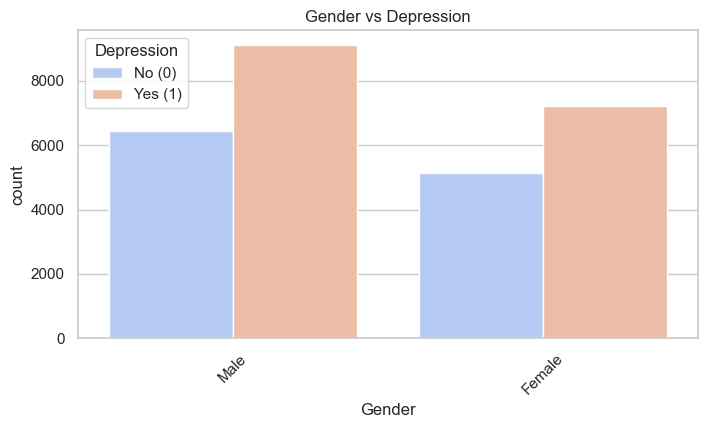


===== City vs Depression =====


Depression,0,1
City,,
'Less Delhi',1.00,0.00
'Less than 5 Kalyan',1.00,0.00
3.0,0.00,1.00
Agra,0.47,0.53
Ahmedabad,0.33,0.67
Bangalore,0.39,0.61
Bhavna,0.00,1.00
Bhopal,0.38,0.62
Chennai,0.40,0.60


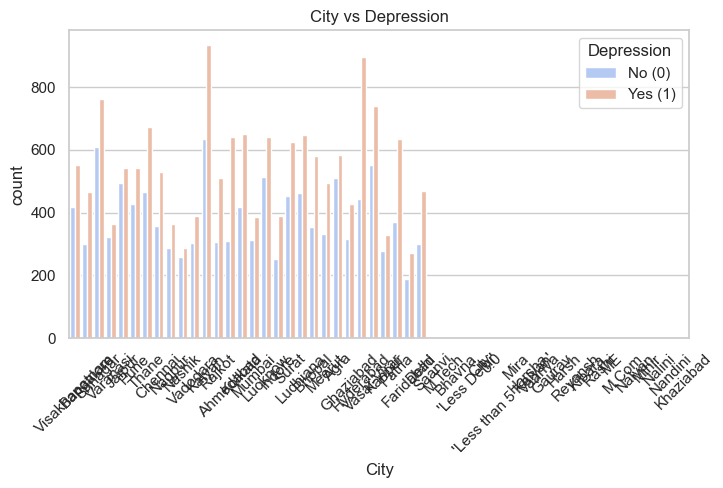


===== Profession vs Depression =====


Depression,0,1
Profession,,
'Civil Engineer',0.00,1.00
'Content Writer',0.00,1.00
'Digital Marketer',0.33,0.67
'Educational Consultant',0.00,1.00
'UX/UI Designer',0.00,1.00
Architect,0.12,0.88
Chef,0.00,1.00
Doctor,0.00,1.00
Entrepreneur,0.00,1.00


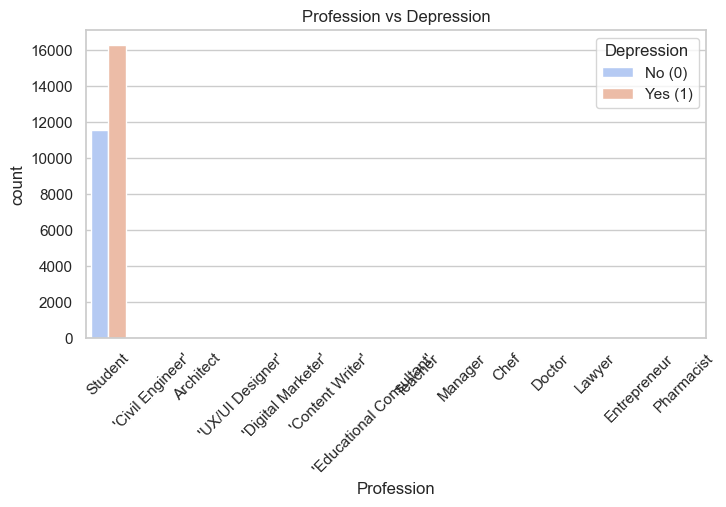


===== Sleep Duration vs Depression =====


Depression,0,1
Sleep Duration,,
'5-6 hours',0.43,0.57
'7-8 hours',0.40,0.60
'Less than 5 hours',0.35,0.65
'More than 8 hours',0.49,0.51
Others,0.50,0.50


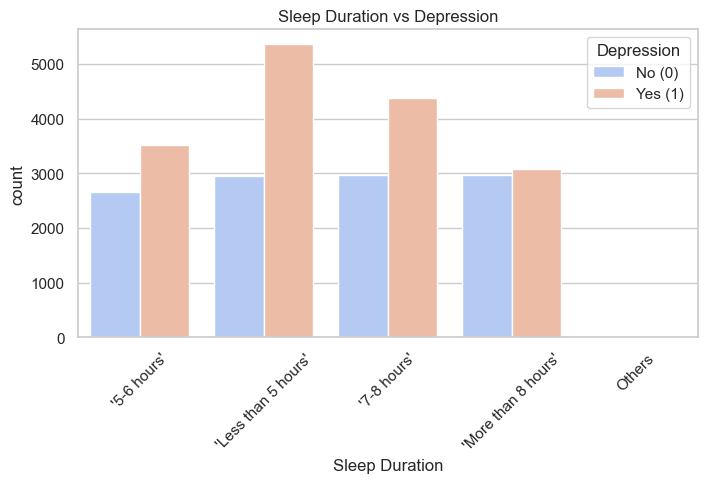


===== Dietary Habits vs Depression =====


Depression,0,1
Dietary Habits,,
Healthy,0.55,0.45
Moderate,0.44,0.56
Others,0.33,0.67
Unhealthy,0.29,0.71


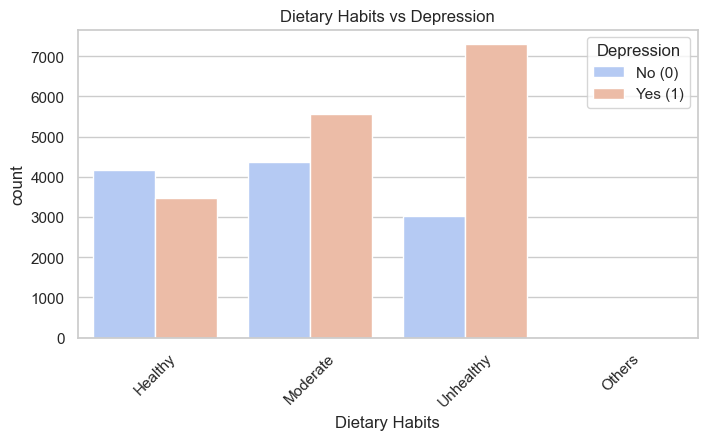


===== Degree vs Depression =====


Depression,0,1
Degree,,
'Class 12',0.29,0.71
B.Arch,0.41,0.59
B.Com,0.43,0.57
B.Ed,0.45,0.55
B.Pharm,0.47,0.53
B.Tech,0.43,0.57
BA,0.46,0.54
BBA,0.42,0.58
BCA,0.43,0.57


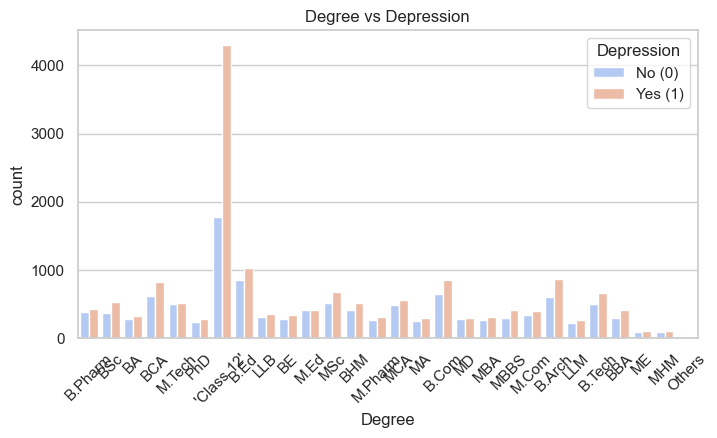


===== Have you ever had suicidal thoughts ? vs Depression =====


Depression,0,1
Have you ever had suicidal thoughts ?,,
No,0.77,0.23
Yes,0.21,0.79


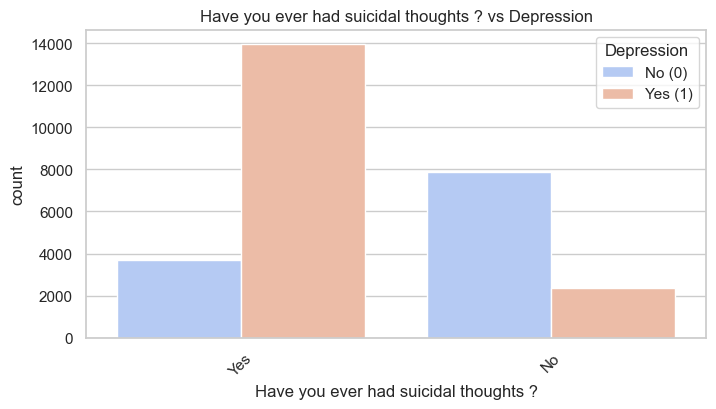


===== Financial Stress vs Depression =====


Depression,0,1
Financial Stress,,
1.0,0.68,0.32
2.0,0.57,0.43
3.0,0.41,0.59
4.0,0.31,0.69
5.0,0.19,0.81
?,0.67,0.33


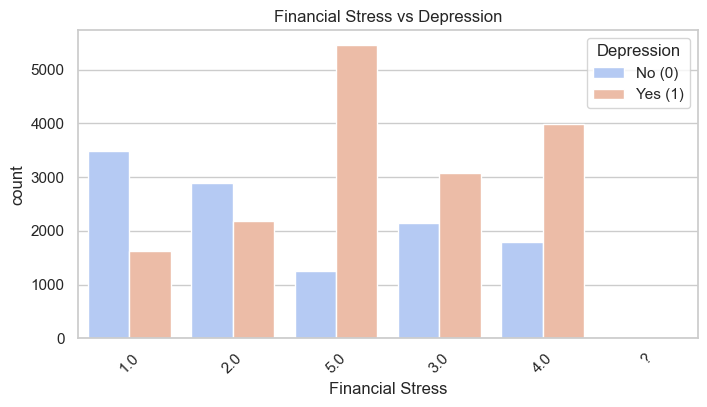


===== Family History of Mental Illness vs Depression =====


Depression,0,1
Family History of Mental Illness,,
No,0.44,0.56
Yes,0.39,0.61


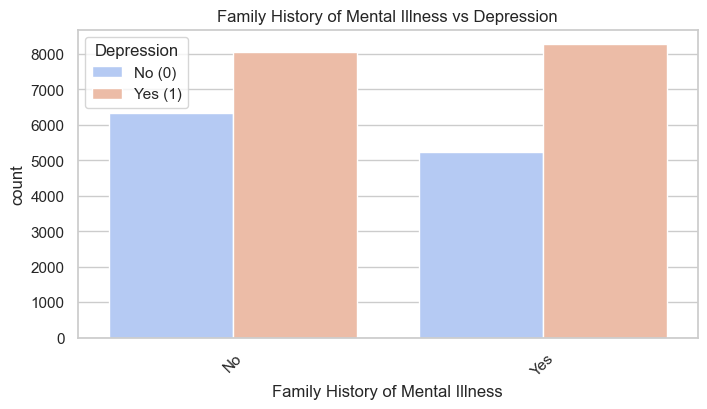

In [22]:
for col in cat_cols:
     if col != target_col:
        print(f"\n===== {col} vs Depression =====")
        display(pd.crosstab(df[col], df[target_col], normalize="index").round(2))

        plt.figure(figsize=(8,4))
        sns.countplot(x=col, hue=target_col, data=df, palette="coolwarm")
        plt.title(f"{col} vs Depression")
        plt.xticks(rotation=45)
        plt.legend(title="Depression", labels=["No (0)", "Yes (1)"])
        plt.show()

## II. DATA PREPARATION

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

### 1. COLUMN REMOVAL

In [24]:
df_prep = df.copy()

if 'id' in df_prep.columns:
    df_prep = df_prep.drop(columns=['id'])

drop_cols = ['City', 'Degree', 'Profession', 'Work Pressure', 'Job Satisfaction']
df_prep = df_prep.drop(columns=drop_cols)

### 2. CATEGORIZING FEATURES

In [25]:
continuous_cols = ['Age', 'CGPA', 'Work/Study Hours']

ordinal_cols = ['Academic Pressure',
                'Study Satisfaction']

categorical_cols = ['Gender',
                    'City',
                    'Profession',
                    'Sleep Duration',
                    'Dietary Habits',
                    'Degree',
                    'Social Weakness',
                    'Have you ever had suicidal thoughts ?',
                    'Financial Stress',
                    'Family History of Mental Illness']

print("Continuous cols :", continuous_cols)
print("Ordinal cols    :", ordinal_cols)
print("Categorical cols:", categorical_cols)

Continuous cols : ['Age', 'CGPA', 'Work/Study Hours']
Ordinal cols    : ['Academic Pressure', 'Study Satisfaction']
Categorical cols: ['Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Social Weakness', 'Have you ever had suicidal thoughts ?', 'Financial Stress', 'Family History of Mental Illness']


### 3. HANDLING MISSING & DUPLICATE VALUES

In [26]:
print(df_prep.isnull().sum())
df_prep = df_prep.dropna()

df_prep = df_prep.drop_duplicates()
print("Duplicate rows after removal:", df_prep.duplicated().sum())


Gender                                   0
Age                                      0
Academic Pressure                        0
CGPA                                     0
Study Satisfaction                       0
Sleep Duration                           0
Dietary Habits                           0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64
Duplicate rows after removal: 0


In [27]:
df_prep["Financial Stress"] = df_prep["Financial Stress"].astype(str).str.strip()

# Hitung jumlah tanda "?"
jumlah_tanda_tanya = (df_prep["Financial Stress"] == "?").sum()
print("Jumlah data dengan nilai '?' pada Financial Stress:", jumlah_tanda_tanya)
print("Jumlah baris sebelum dihapus:", len(df_prep))

# Hapus baris dengan nilai "?"
df_prep = df_prep[df_prep["Financial Stress"] != "?"].reset_index(drop=True)

print("Jumlah baris sesudah dihapus:", len(df_prep))
print("\nUnique values Financial Stress setelah cleaning:")
print(df_prep["Financial Stress"].unique())

Jumlah data dengan nilai '?' pada Financial Stress: 3
Jumlah baris sebelum dihapus: 27899
Jumlah baris sesudah dihapus: 27896

Unique values Financial Stress setelah cleaning:
['1.0' '2.0' '5.0' '3.0' '4.0']


### 4. ENCODING

In [28]:
!pip install category-encoders
from sklearn.preprocessing import LabelEncoder
from category_encoders.target_encoder import TargetEncoder

df_encoded = df_prep.copy()

Access is denied.


In [29]:
df_encoded['Sleep Duration'] = (
    df_encoded['Sleep Duration']
    .astype(str)
    .str.replace("'", "")
    .str.strip()
)

In [30]:
# BINARY ENCODING
ordinal_mapping = {
    "Sleep Duration": {
        "Less than 5 hours": 1,
        "5-6 hours": 2,
        "7-8 hours": 3,
        "More than 8 hours": 4,
        "Others": 0
    },
    "Financial Stress": {
        "1.0": 1, "2.0": 2, "3.0": 3, "4.0": 4, "5.0": 5
    },
    "Have you ever had suicidal thoughts ?": {"No": 0, "Yes": 1},
    "Family History of Mental Illness": {"No": 0, "Yes": 1}
}

for col, mapping in ordinal_mapping.items():
    if col in df_encoded.columns:
        df_encoded[col] = df_encoded[col].map(mapping).fillna(0).astype(float)


# LABEL ENCODING
label_cols = ['Gender', 'Dietary Habits']

print("\nApplying Label Encoding to:", label_cols)

le = LabelEncoder()

for col in label_cols:
    if col in df_encoded.columns:
        df_encoded[col] = df_encoded[col].astype(str)
        df_encoded[col] = le.fit_transform(df_encoded[col])


print("\nEncoding Complete")
print("\nData Types After Encoding:\n")
print(df_encoded.dtypes)

print("\nSample Preview:\n")
df_encoded.head()


Applying Label Encoding to: ['Gender', 'Dietary Habits']

Encoding Complete

Data Types After Encoding:

Gender                                     int64
Age                                      float64
Academic Pressure                        float64
CGPA                                     float64
Study Satisfaction                       float64
Sleep Duration                           float64
Dietary Habits                             int64
Have you ever had suicidal thoughts ?    float64
Work/Study Hours                         float64
Financial Stress                         float64
Family History of Mental Illness         float64
Depression                                 int64
dtype: object

Sample Preview:



,Gender,Age,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,1,33.0,5.0,8.97,2.0,2.0,0,1.0,3.0,1.0,0.0,1
1,0,24.0,2.0,5.90,5.0,2.0,1,0.0,3.0,2.0,1.0,0
2,1,31.0,3.0,7.03,5.0,1.0,0,0.0,9.0,1.0,1.0,0
3,0,28.0,3.0,5.59,2.0,3.0,1,1.0,4.0,5.0,1.0,1
4,0,25.0,4.0,8.13,3.0,2.0,1,1.0,1.0,1.0,0.0,0


### 5. HANDLING OUTLIERS

In [31]:
outlier_cols = ['Age', 'CGPA']

def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    return df

for col in outlier_cols:
    df_encoded = cap_outliers(df_encoded, col)


In [32]:
print("\nRechecking outliers after capping:")

for col in outlier_cols:
    Q1 = df_encoded[col].quantile(0.25)
    Q3 = df_encoded[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df_encoded[(df_encoded[col] < lower) | (df_encoded[col] > upper)]
    print(f"{col} -> Remaining Outliers: {len(outliers)}")



Rechecking outliers after capping:
Age -> Remaining Outliers: 0
CGPA -> Remaining Outliers: 0


In [33]:
print(df_encoded.isnull().sum())

Gender                                   0
Age                                      0
Academic Pressure                        0
CGPA                                     0
Study Satisfaction                       0
Sleep Duration                           0
Dietary Habits                           0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64


### 6. DISTRIBUTION AFTER ENCODING

Total Numeric Columns: 12


<Figure size 2500x1200 with 0 Axes>

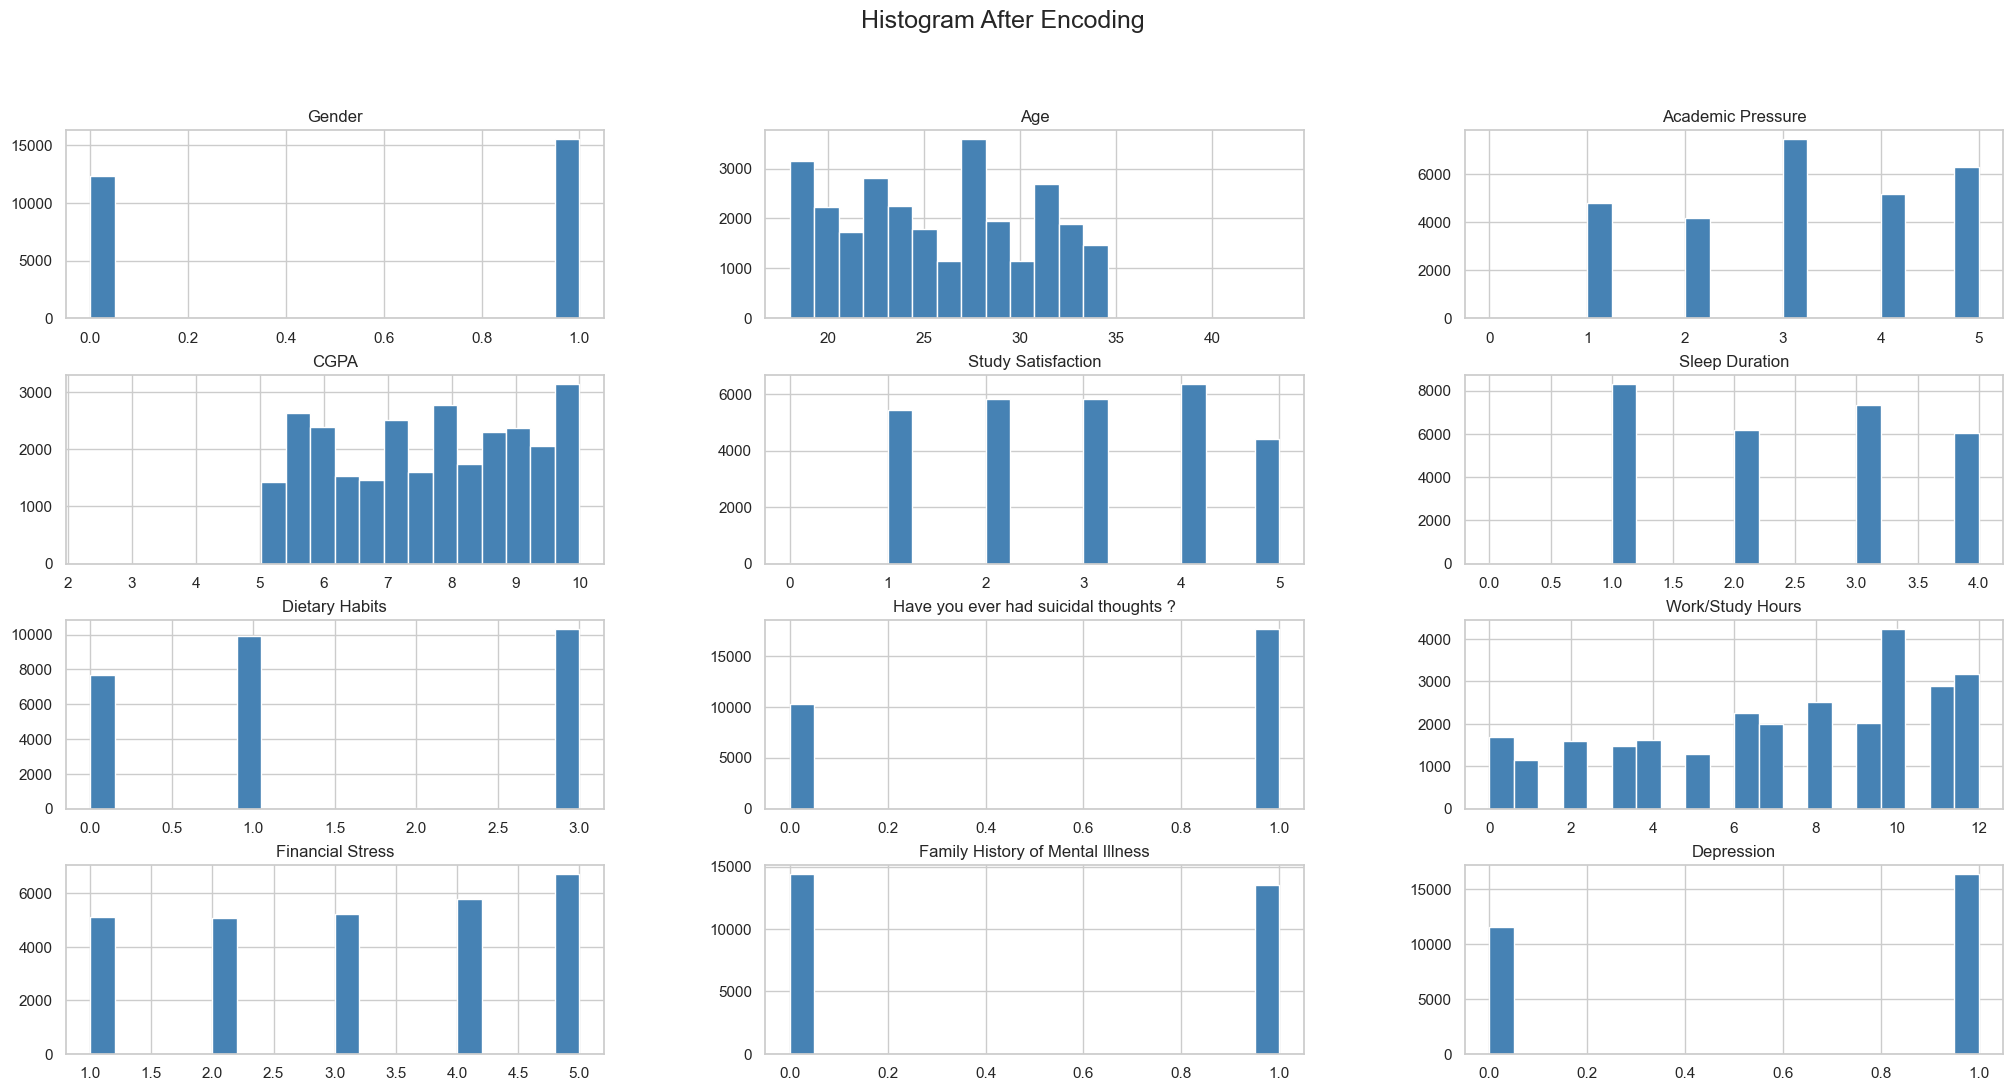

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df_encoded.select_dtypes(include=['int64', 'float64']).columns

print(f"Total Numeric Columns: {len(num_cols)}")

plt.figure(figsize=(25, 12))
df_encoded[num_cols].hist(bins=20, figsize=(25, 12), color='steelblue')
plt.suptitle("Histogram After Encoding", fontsize=18)
plt.show()



### 7. CORELATION AFTER ENCODING

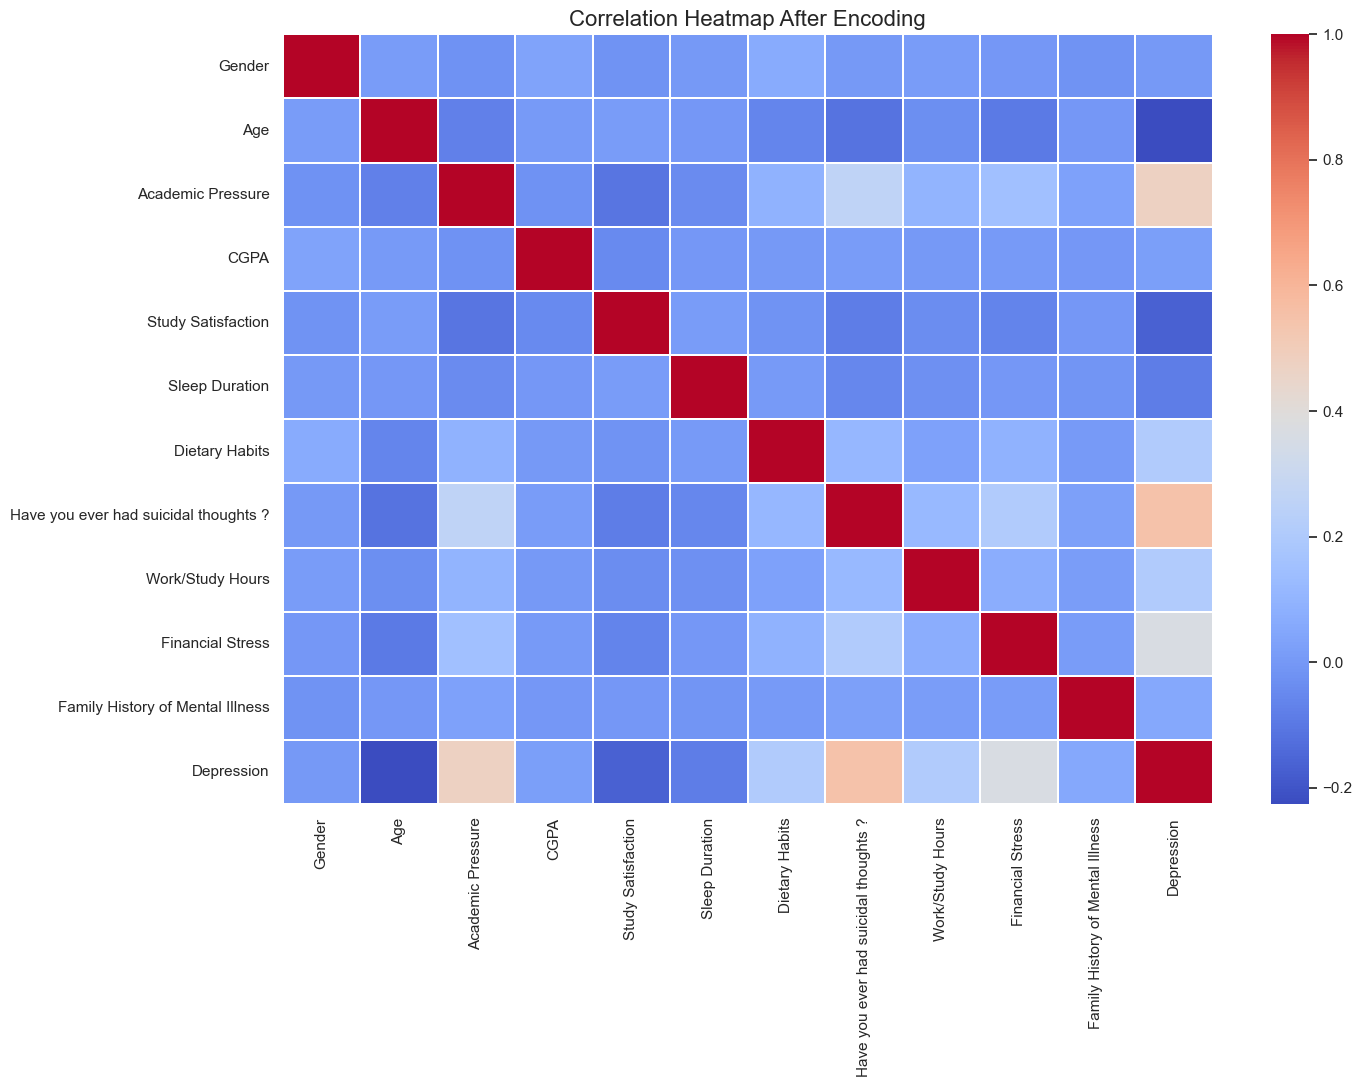

In [35]:
corr = df_encoded.corr()

plt.figure(figsize=(15, 10))
sns.heatmap(corr, cmap="coolwarm", annot=False, linewidths=0.3)
plt.title("Correlation Heatmap After Encoding", fontsize=16)
plt.show()


C:\Users\leciti\AppData\Local\Temp\ipykernel_17436\2847899685.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_target.values, y=corr_target.index, palette="coolwarm")


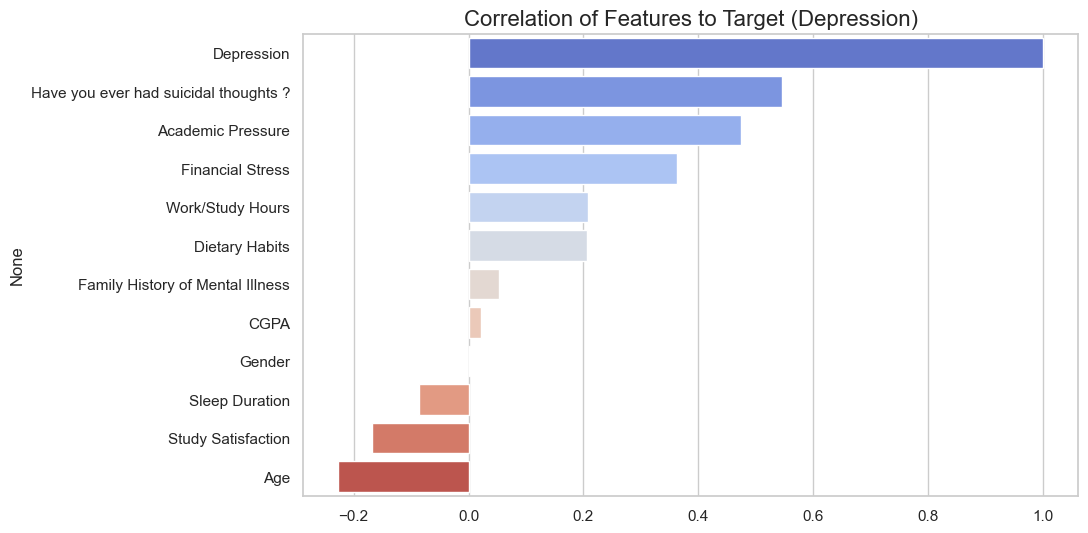

In [36]:
target = "Depression"

corr_target = corr[target].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=corr_target.values, y=corr_target.index, palette="coolwarm")
plt.title(f"Correlation of Features to Target ({target})", fontsize=16)
plt.show()


### 8. STANDARIZATION

In [37]:
from sklearn.preprocessing import StandardScaler

df_scaled = df_encoded.copy()

feature_cols = df_scaled.columns[df_scaled.columns != 'Depression']

scaler = StandardScaler()
df_scaled[feature_cols] = scaler.fit_transform(df_scaled[feature_cols])

df_scaled.head()


,Gender,Age,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0.891430,1.468143,1.345502,0.894933,-0.693493,-0.352391,-1.182394,0.761618,-1.121047,-1.488846,-0.968450,1
1,-1.121793,-0.371875,-0.826235,-1.197287,1.510556,-0.352391,-0.375721,-1.312994,-1.121047,-0.793083,1.032578,0
2,0.891430,1.059250,-0.102322,-0.427186,1.510556,-1.238961,-1.182394,-1.312994,0.497289,-1.488846,1.032578,0
3,-1.121793,0.445911,-0.102322,-1.408554,-0.693493,0.534180,-0.375721,0.761618,-0.851324,1.294204,1.032578,1
4,-1.121793,-0.167428,0.621590,0.322469,0.041190,-0.352391,-0.375721,0.761618,-1.660492,-1.488846,-0.968450,0


### 9. TRAIN-SPLIT (80-20)

In [38]:
from sklearn.model_selection import train_test_split

X = df_scaled.drop(columns=['Depression'])
y = df_scaled['Depression']

# Train-test split dengan stratifikasi
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nDistribusi Target di Training Set:")
print(y_train.value_counts(normalize=True) * 100)

print("\nDistribusi Target di Test Set:")
print(y_test.value_counts(normalize=True) * 100)


Train shape: (22316, 11)
Test shape: (5580, 11)

Distribusi Target di Training Set:
Depression
1    58.5544
0    41.4456
Name: proportion, dtype: float64

Distribusi Target di Test Set:
Depression
1    58.548387
0    41.451613
Name: proportion, dtype: float64


## III. MODELLING

### GRADIENT BOOSTING CLASSIFIER

In [61]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report, confusion_matrix
)
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Train Model 
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gb_model.fit(X_train, y_train)

# 2. Predictions
y_pred_gb = gb_model.predict(X_test)
y_pred_train_gb = gb_model.predict(X_train)

# 3. Evaluation Metrics 
accuracy = accuracy_score(y_test, y_pred_gb)
precision = precision_score(y_test, y_pred_gb)
recall = recall_score(y_test, y_pred_gb)
f1 = f1_score(y_test, y_pred_gb)

# 4. ROC-AUC 
y_pred_proba_gb = gb_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba_gb)

# 5. Overfitting Check 
train_accuracy = accuracy_score(y_train, y_pred_train_gb)
test_accuracy = accuracy_score(y_test, y_pred_gb)

# 6. Cross Validation 
cv_scores = cross_val_score(gb_model, X_train, y_train, cv=5, scoring='accuracy')


In [62]:
print("\nGRADIENT BOOSTING MODEL PERFORMANCE")
print(f"Accuracy       : {accuracy:.4f}")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1-Score       : {f1:.4f}")
print(f"ROC-AUC Score  : {roc_auc:.4f}")

print("\nOVERFITTING CHECK")
print(f"Train Accuracy : {train_accuracy:.4f}")
print(f"Test Accuracy  : {test_accuracy:.4f}")

print("\nCROSS VALIDATION (5-FOLD)")
print("CV Scores      :", cv_scores)
print(f"Mean Accuracy  : {cv_scores.mean():.4f}")
print(f"Std Deviation  : {cv_scores.std():.4f}")

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred_gb))


GRADIENT BOOSTING MODEL PERFORMANCE
Accuracy       : 0.8482
Precision      : 0.8597
Recall         : 0.8852
F1-Score       : 0.8723
ROC-AUC Score  : 0.9239

OVERFITTING CHECK
Train Accuracy : 0.8514
Test Accuracy  : 0.8482

CROSS VALIDATION (5-FOLD)
CV Scores      : [0.84408602 0.83822541 0.84853238 0.85054896 0.84808425]
Mean Accuracy  : 0.8459
Std Deviation  : 0.0044

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.83      0.80      0.81      2313
           1       0.86      0.89      0.87      3267

    accuracy                           0.85      5580
   macro avg       0.85      0.84      0.84      5580
weighted avg       0.85      0.85      0.85      5580



- True Negative (TN): 79,6%
- False Positive (FP): 20,4%
- False Negative (FN): 11,5%
- True Positive (TP): 88,5%

### 2. OPTIMIZATION : GBoost

### 2.1 BEST HYPERPARAMETERS

In [66]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
     'learning_rate': [0.03, 0.04, 0.05],  
    'n_estimators': [250, 300, 350, 400, 500],  
    'max_depth': [3, 4, 5],  
    'subsample': [0.8, 0.9, 1.0],  
    'max_features': ['sqrt', 'log2'] 
}

gb_model = GradientBoostingClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)


print("\nBEST HYPERPARAMETERS FROM GRID SEARCH")
print(grid_search.best_params_)

print("\BEST CROSS-VALIDATED F1 SCORE")
print(grid_search.best_score_)


Fitting 5 folds for each of 270 candidates, totalling 1350 fits

BEST HYPERPARAMETERS FROM GRID SEARCH
{'learning_rate': 0.05, 'max_depth': 3, 'max_features': 'sqrt', 'n_estimators': 300, 'subsample': 1.0}
\BEST CROSS-VALIDATED F1 SCORE
0.8721689641663712


In [67]:
best_gb = grid_search.best_estimator_

y_pred_best = best_gb.predict(X_test)

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

print("\nFINAL PERFORMANCE")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_best):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_best):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, best_gb.predict_proba(X_test)[:,1]):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))


FINAL PERFORMANCE
Accuracy  : 0.8516
Precision : 0.8626
Recall    : 0.8880
F1-Score  : 0.8751
ROC-AUC   : 0.9242

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.80      0.82      2313
           1       0.86      0.89      0.88      3267

    accuracy                           0.85      5580
   macro avg       0.85      0.84      0.85      5580
weighted avg       0.85      0.85      0.85      5580



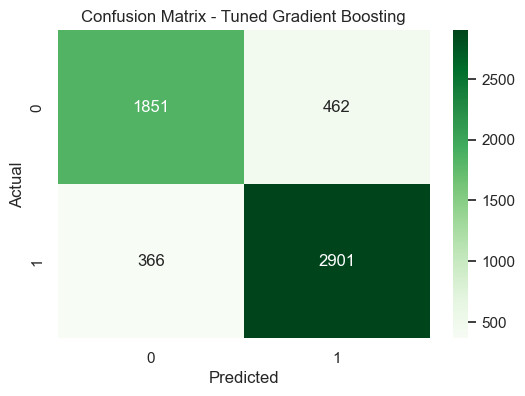

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Greens", fmt='d')
plt.title("Confusion Matrix - Tuned Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()